# Storage Data

### In this notebook we show how save the data of the simulation

In [1]:
import sys
sys.path.append('..')
import numpy as np
from dirac_solver.geometry import Grid
from dirac_solver.initial_state import GaussianPacket, ConstantSpinor
from dirac_solver.core import DiracProblemBuilder, DiracSolver
from dirac_solver import _core

# This is the new:
from pathlib import Path
from datetime import datetime
from dirac_solver.storage import HDF5Storage


In [2]:
shape = (400,)
spacing = (0.1,)
grid = Grid(shape, spacing)

constant_spinor = ConstantSpinor(momentum=[10, 0, 0])
initial_state = GaussianPacket(constant_spinor, center=[0, 0, 0], spatial_width=1.0)

def potential_well(r):
    x = r[0]
    if -5 < x < 5:
        return 0.0
    return 20.0

potential = _core.ScalarPotential(potential_well)
boundary_condition = _core.AbsorbingBoundary(strength=0.1)

problem = DiracProblemBuilder() \
    .set_grid(grid) \
    .set_initial_state(initial_state) \
    .set_potential(potential) \
    .set_boundary_condition(boundary_condition) \
    .set_time_parameters(time_step=0.001, total_time=10.0) \
    .build()

In [4]:
DATA_DIR = Path("../save_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

now = datetime.now()

timestamp = now.strftime("%Y-%m-%d_%H-%M-%S")

output_path = DATA_DIR / f"{timestamp}.hdf5"

print(f"Se guardarán los datos en: {output_path}")

Se guardarán los datos en: ../save_data/2025-11-10_10-23-46.hdf5


--- Iniciando simulación con almacenamiento ---
HDF5Storage inicializado. Guardando datos en: ../save_data/2025-11-10_10-23-46.hdf5
DiracSolver inicializado con el motor C++ 'FDTDLeapfrogIntegrator'.
Ejecutando simulación por 10000 pasos...
Guardando snapshot inicial (t=0.0).
  Paso 10/10000 completado.
  Paso 20/10000 completado.
  Paso 30/10000 completado.
  Paso 40/10000 completado.
  Paso 50/10000 completado.
  Paso 60/10000 completado.
  Paso 70/10000 completado.
  Paso 80/10000 completado.
  Paso 90/10000 completado.
  Paso 100/10000 completado.
  Paso 110/10000 completado.
  Paso 120/10000 completado.
  Paso 130/10000 completado.
  Paso 140/10000 completado.
  Paso 150/10000 completado.
  Paso 160/10000 completado.
  Paso 170/10000 completado.
  Paso 180/10000 completado.
  Paso 190/10000 completado.
  Paso 200/10000 completado.
  Paso 210/10000 completado.
  Paso 220/10000 completado.
  Paso 230/10000 completado.
  Paso 240/10000 completado.
  Paso 250/10000 completado.
  Paso 

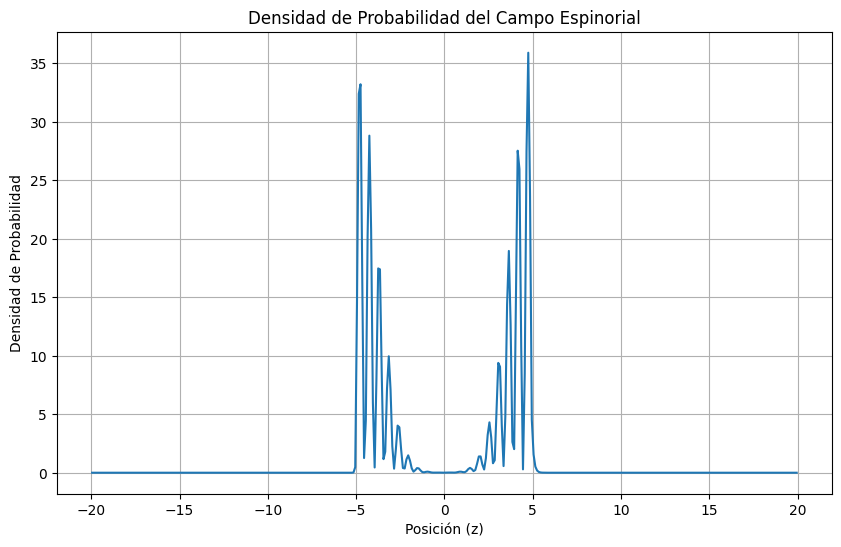

In [5]:
print("--- Iniciando simulación con almacenamiento ---")
with HDF5Storage(filepath=output_path, problem=problem) as storage:

    solver = DiracSolver(problem)
    
    solver.run_simulation(
        storage_handler=storage, 
        save_every_n_steps=1000  
    )

print("--- Simulación finalizada ---")

solver.plot_probability_density()